In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
path = "/Users/sayasatsabit/Downloads/loan_approval_dataset.csv"
df = pd.read_csv(path)

In [5]:
print("Shape:", df.shape)
df.head()

Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [7]:
df.columns = [col.replace(" ", "") for col in df.columns]

In [8]:
if "loan_id" in df.columns:
    df = df.drop("loan_id", axis=1)

In [11]:
label_encoder = LabelEncoder()

for col in ["education", "self_employed", "loan_status"]:
    if col in df.columns:
        df[col] = label_encoder.fit_transform(df[col])

In [12]:
df.dtypes

no_of_dependents            int64
education                   int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                 int64
dtype: object

In [13]:
y = df["loan_status"].values
X = df.drop("loan_status", axis=1).values

In [14]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [15]:
pca = PCA(n_components=5)
X_pca_5 = pca.fit_transform(X_std)

In [16]:
explained_var_ratio = pca.explained_variance_ratio_
cumulative_var_ratio = np.cumsum(explained_var_ratio)

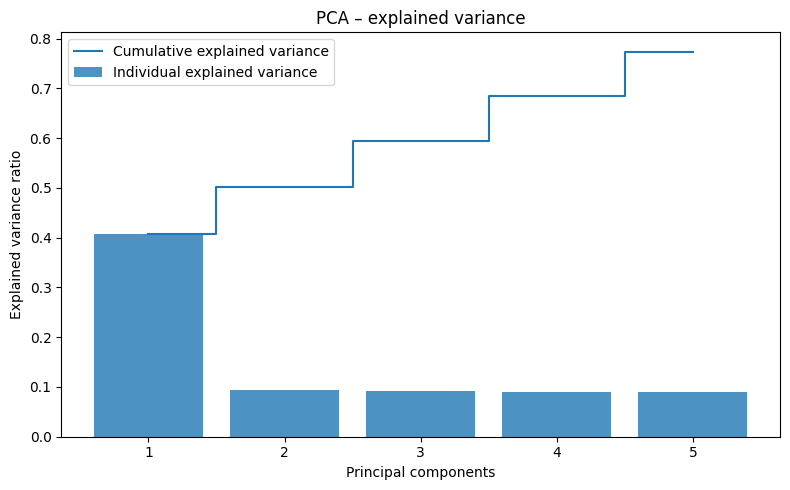

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(
    range(1, 6),
    explained_var_ratio,
    alpha=0.8,
    align="center",
    label="Individual explained variance"
)
plt.step(
    range(1, 6),
    cumulative_var_ratio,
    where="mid",
    label="Cumulative explained variance"
)
plt.xlabel("Principal components")
plt.ylabel("Explained variance ratio")
plt.title("PCA – explained variance")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [18]:
pc_cols = [f"PC{i}" for i in range(1, 6)]
pc_df = pd.DataFrame(X_pca_5, columns=pc_cols)
pc_df["loan_status"] = y

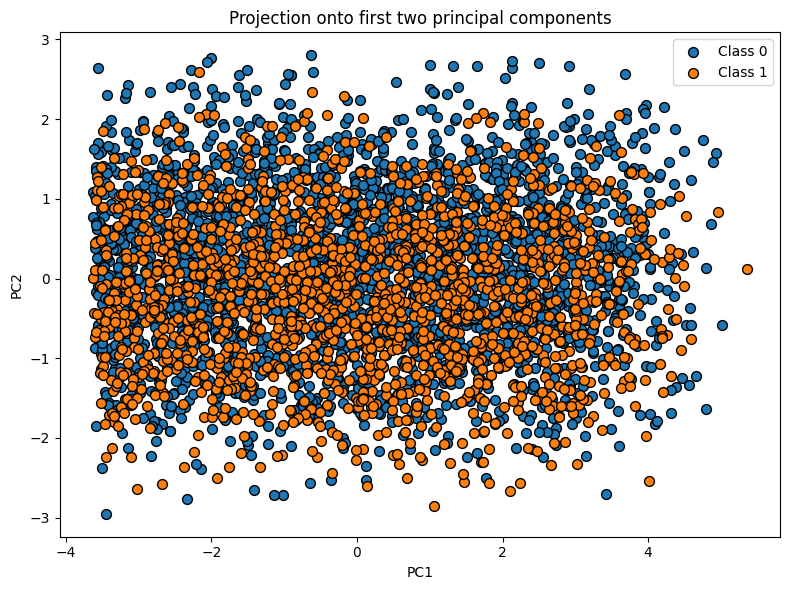

In [19]:
plt.figure(figsize=(8, 6))
for label in np.unique(y):
    plt.scatter(
        pc_df.loc[pc_df["loan_status"] == label, "PC1"],
        pc_df.loc[pc_df["loan_status"] == label, "PC2"],
        label=f"Class {label}",
        edgecolor="black",
        s=50
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection onto first two principal components")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
pca2 = PCA(n_components=2)
X_pca_2 = pca2.fit_transform(X_std)

In [33]:
km = KMeans(
    n_clusters=2,
    init="random",
    n_init=10,
    max_iter=300,
    tol=1e-04,
    random_state=0
)

y_km = km.fit_predict(X_std)

In [34]:
km.cluster_centers_

array([[-0.02433482,  0.02295231,  0.001064  , -0.83887556, -0.79103051,
        -0.00314072,  0.02320654, -0.56807558, -0.58926645, -0.79534377,
        -0.7404571 ],
       [ 0.02497004, -0.02355144, -0.00109177,  0.86077312,  0.81167915,
         0.00322271, -0.02381231,  0.58290432,  0.60464834,  0.816105  ,
         0.7597856 ]])

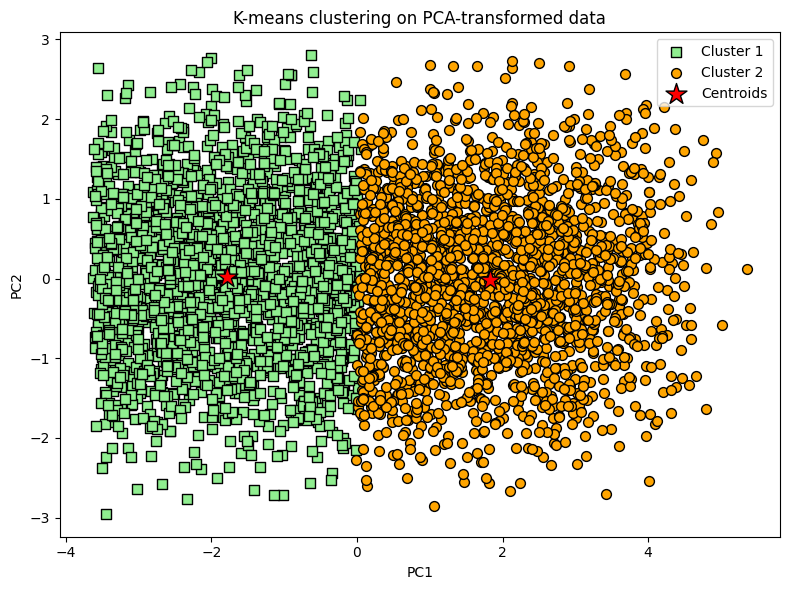

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca_2[y_km == 0, 0],
    X_pca_2[y_km == 0, 1],
    s=50,
    c="lightgreen",
    marker="s",
    edgecolor="black",
    label="Cluster 1"
)
plt.scatter(
    X_pca_2[y_km == 1, 0],
    X_pca_2[y_km == 1, 1],
    s=50,
    c="orange",
    marker="o",
    edgecolor="black",
    label="Cluster 2"
)
# plt.scatter(
#     X_pca_2[y_km == 2, 0],
#     X_pca_2[y_km == 2, 1],
#     s=50,
#     c="lightblue",
#     marker="^",
#     edgecolor="black",
#     label="Cluster 3"
# )
centers_pca = pca2.transform(km.cluster_centers_)
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    s=250,
    marker="*",
    c="red",
    edgecolor="black",
    label="Centroids"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(scatterpoints=1)
plt.title("K-means clustering on PCA-transformed data")
plt.tight_layout()
plt.show()

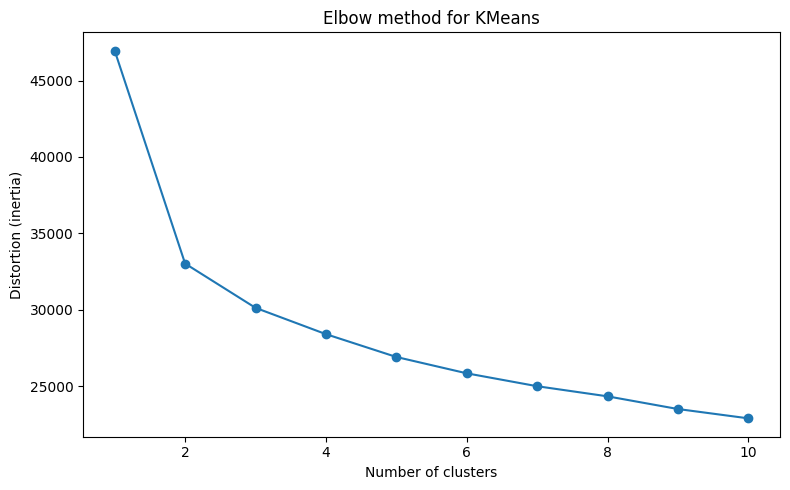

In [36]:
distortions = []
cluster_range = range(1, 11)

for i in cluster_range:
    km_elbow = KMeans(
        n_clusters=i,
        init="random",
        n_init=10,
        max_iter=300,
        tol=1e-04,
        random_state=0
    )
    km_elbow.fit(X_std)
    distortions.append(km_elbow.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, distortions, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Distortion (inertia)")
plt.title("Elbow method for KMeans")
plt.tight_layout()
plt.show()

In [28]:
ac = AgglomerativeClustering(
    n_clusters=3,
    linkage="complete",   # как у Рашки: 'complete'
    metric="euclidean"    # в новых версиях вместо affinity
)

y_ac = ac.fit_predict(X_std)

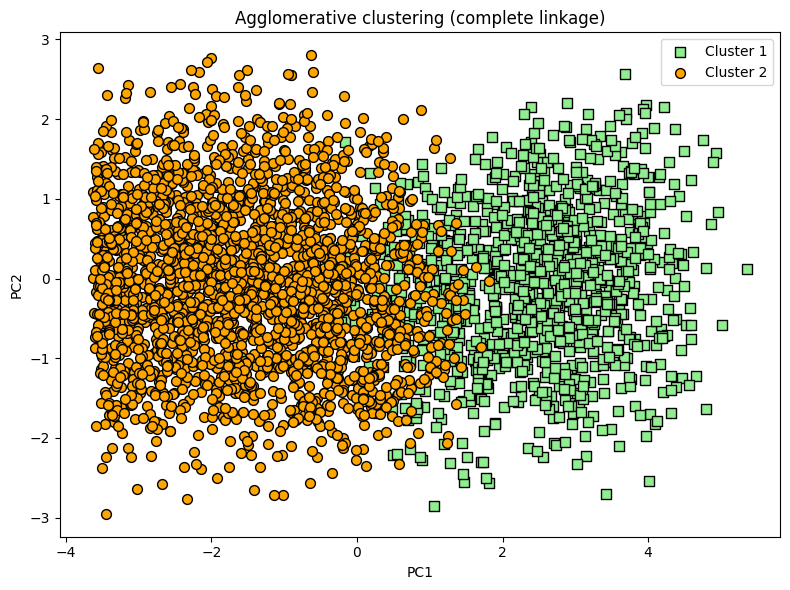

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca_2[y_ac == 0, 0],
    X_pca_2[y_ac == 0, 1],
    s=50,
    c="lightgreen",
    marker="s",
    edgecolor="black",
    label="Cluster 1"
)
plt.scatter(
    X_pca_2[y_ac == 1, 0],
    X_pca_2[y_ac == 1, 1],
    s=50,
    c="orange",
    marker="o",
    edgecolor="black",
    label="Cluster 2"
)
# plt.scatter(
#     X_pca_2[y_ac == 2, 0],
#     X_pca_2[y_ac == 2, 1],
#     s=50,
#     c="lightblue",
#     marker="^",
#     edgecolor="black",
#     label="Cluster 3"
# )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(scatterpoints=1)
plt.title("Agglomerative clustering (complete linkage)")
plt.tight_layout()
plt.show()

In [38]:
db = DBSCAN(
    eps=0.7,         
    min_samples=5,    
    metric="euclidean",
    n_jobs=-1
)

y_db = db.fit_predict(X_pca_2) 

In [39]:
np.unique(y_db)

array([0])

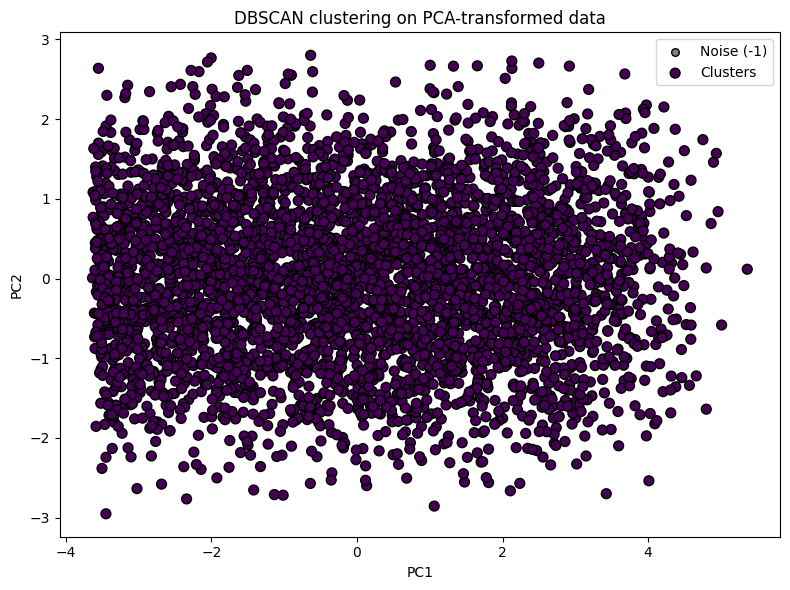

In [40]:
plt.figure(figsize=(8, 6))

# шум (label = -1)
mask_noise = (y_db == -1)
mask_core = (y_db != -1)

plt.scatter(
    X_pca_2[mask_noise, 0],
    X_pca_2[mask_noise, 1],
    s=30,
    c="grey",
    edgecolor="black",
    label="Noise (-1)"
)

plt.scatter(
    X_pca_2[mask_core, 0],
    X_pca_2[mask_core, 1],
    s=50,
    c=y_db[mask_core],
    cmap="viridis",
    edgecolor="black",
    label="Clusters"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN clustering on PCA-transformed data")
plt.legend()
plt.tight_layout()
plt.show()